# Supplementary: Vision API guide

This notebook is a short reference for `shapiq.vision`. It starts with a tiny numpy-only example, then walks through the usual ResNet workflow on a real image: superpixel players, mean-color masking, coalition evaluation, and an attribution plot.

For deeper dives see the other supplementary notebooks (`player_strategies.ipynb`, `masking_strategies.ipynb`, `architecture_defaults.ipynb`, `batching_details.ipynb`) and the main tutorials in the parent folder.

## Package layout

The vision code lives in `shapiq.vision` and follows the same pattern as `shapiq.tree`.

| Module | Role |
|--------|------|
| `architecture.py` | Wraps a model and defines how coalitions are evaluated |
| `players.py` | Splits the image into players (patches, superpixels, custom masks) |
| `masking.py` | Fills in regions for absent players (mean color, zero, blur, ViT tokens) |
| `imputer.py` | `ImageImputer`, the game that batches coalition evaluations |
| `explainer.py` | `ImageExplainer`, wired to the approximator pipeline |
| `utils.py` | Converts numpy, PIL, and PyTorch inputs to `(H, W, C)` arrays |

Most workflows start with `ImageExplainer` or the top-level `shapiq.Explainer` factory.

## Setup

The first example uses only numpy. The real-image section loads `dog.png` and ResNet-18 from torchvision (~45 MB on first run).


In [12]:
from __future__ import annotations

import numpy as np
import torch

from shapiq import Explainer, ImageExplainer
from shapiq.vision import GridStrategy, ResNetArchitecture, ZeroMasking

## Minimal example

You need three pieces:

1. An image as a numpy array with shape `(H, W, C)`
2. A model callable that accepts a batch `(B, H, W, C)` and returns scores `(B,)`
3. An architecture strategy that connects the model to the imputer

The callable can be pure numpy, PyTorch, JAX, or anything else as long as it respects that batch layout.

In [2]:
rng = np.random.default_rng(0)
image = rng.integers(0, 255, size=(8, 8, 3)).astype(np.float64)


def mean_brightness(batch: np.ndarray) -> np.ndarray:
    """Return the mean pixel value for each image in the batch."""
    return batch.mean(axis=(1, 2, 3))


architecture = ResNetArchitecture(
    model=mean_brightness,
    masking_strategy=ZeroMasking(),
)

explainer = ImageExplainer(
    architecture=architecture,
    data=image,
    player_strategy=GridStrategy(rows=2, cols=2),
    index="SV",
    max_order=1,
    random_state=0,
)

interaction_values = explainer.explain(budget=32)

print(f"players: {interaction_values.n_players}")
print(f"baseline (empty coalition): {explainer.baseline_value:.4f}")
print(f"first-order values: {interaction_values.get_n_order_values(1)}")

players: 4
baseline (empty coalition): 0.0000
first-order values: [33.46354211 32.14062531 32.31770728 37.07812529]


/Users/alex/IdeaProjects/shapiq/src/shapiq/approximator/regression/base.py:160: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)


`ImageExplainer.explain` runs the approximator on the imputer. The `budget` argument is the number of coalition evaluations. For order-1 Shapley values on four players, a budget of 32 is enough for a stable estimate in this toy setup.

## Using `shapiq.Explainer` auto-dispatch

If you pass image-like `data` to the top-level factory, shapiq selects `ImageExplainer` and wraps a plain callable in `ResNetArchitecture` by default.

In [3]:
auto = Explainer(
    model=mean_brightness,
    data=image,
    player_strategy=GridStrategy(rows=2, cols=2),
    index="SV",
    max_order=1,
    random_state=0,
)

print(type(auto).__name__)
auto_values = auto.explain(budget=32)
print(auto_values.get_n_order_values(1))

ImageExplainer
[-0.28645831 -1.609375   -1.43229166  3.32812498]


/Users/alex/IdeaProjects/shapiq/src/shapiq/approximator/regression/base.py:160: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)


You can also pass a ready-made architecture strategy as `model`. The factory detects that it is already a strategy and uses it directly.

In [4]:
explicit = Explainer(
    model=architecture,
    data=image,
    player_strategy=GridStrategy(rows=2, cols=2),
    random_state=0,
)

print(explicit.imputer.architecture is architecture)

True


## Image inputs

`ImageExplainer` and `ImageImputer` accept numpy arrays, PIL images, and PyTorch tensors. Everything is converted internally with `as_hwc_array` to shape `(H, W, C)`.

In [5]:
from PIL import Image

from shapiq.vision import as_hwc_array, is_image_like

pil_image = Image.fromarray(image.astype(np.uint8), mode="RGB")

print("numpy:", as_hwc_array(image).shape)
print("PIL:", as_hwc_array(pil_image).shape)
print("is_image_like(pil_image):", is_image_like(pil_image))
print("is_image_like tabular matrix:", is_image_like(np.zeros((100, 20))))

numpy: (8, 8, 3)
PIL: (8, 8, 3)
is_image_like(pil_image): True
is_image_like tabular matrix: False


Grayscale arrays with shape `(H, W)` get a channel axis. Channel-first tensors `(C, H, W)` are transposed automatically.

## Defaults and overrides

Each architecture class defines default player and masking strategies. For `ResNetArchitecture` the defaults are superpixels plus mean-color masking. You can override them on the explainer without touching the architecture object.

In [6]:
from shapiq.vision import MeanColorMasking

arch_defaults = ResNetArchitecture(model=mean_brightness)

print("default player:", type(arch_defaults.default_player_strategy()).__name__)
print("default masking:", type(arch_defaults.default_masking_strategy()).__name__)

custom = ImageExplainer(
    architecture=arch_defaults,
    data=image,
    player_strategy=GridStrategy(rows=2, cols=2),
    masking_strategy=MeanColorMasking(),
    batch_size=8,
    index="k-SII",
    max_order=2,
    random_state=0,
)

print("batch_size on imputer:", custom.imputer.batch_size)

default player: SuperpixelStrategy
default masking: MeanColorMasking
batch_size on imputer: 8


See `architecture_defaults.ipynb` for the full table of defaults across ResNet, ViT, ConvNeXt, DINOv2, and CLIP.

## Inspecting the imputer

After construction, the explainer exposes the imputer and the player masks that were cached during `prepare`.

In [7]:
imputer = explainer.imputer
masks = imputer.player_masks

print(f"image shape: {imputer.image.shape}")
print(f"player masks shape: {masks.shape}")
print(f"players per mask sum: {masks.sum(axis=(1, 2))}")

image shape: (8, 8, 3)
player masks shape: (4, 8, 8)
players per mask sum: [16 16 16 16]


## Typical workflow: real image, superpixels, and masking

This is the path most notebooks in this repo follow.

1. Load a `(224, 224, 3)` RGB image
2. Wrap a classifier in `ResNetArchitecture` with `MeanColorMasking`
3. Partition the image with `SuperpixelStrategy`
4. Build masked images for coalitions and run the model in batches via `ImageImputer` or `ImageExplainer`

image shape: (224, 224, 3)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

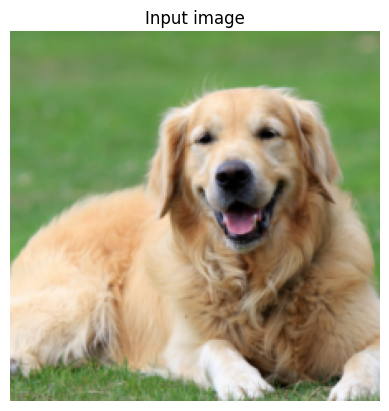

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

import shapiq.vision as vision_pkg

dog_path = Path(vision_pkg.__file__).parent / "dog.png"
pil_224 = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(224),
    ]
)(Image.open(dog_path).convert("RGB"))
image_224 = np.asarray(pil_224)

print("image shape:", image_224.shape)
plt.imshow(image_224)
plt.title("Input image")
plt.axis("off")

### Model, architecture, and player partition

In [9]:
RUN_REAL_EXAMPLE = True

if not RUN_REAL_EXAMPLE:
    print("Skipped real-image example.")
else:
    import torch.nn.functional as F
    from torchvision import models

    from shapiq.vision import MeanColorMasking, SuperpixelStrategy

    device = torch.device("cpu")
    weights = models.ResNet18_Weights.DEFAULT
    resnet = models.resnet18(weights=weights).eval().to(device)
    preprocess = weights.transforms()

    with torch.no_grad():
        logits = resnet(preprocess(pil_224).unsqueeze(0).to(device))
        class_id = int(logits.argmax(-1).item())
    label = weights.meta["categories"][class_id]
    print(f"predicted class: {class_id} ({label})")

    def resnet_callable(batch_hwc: np.ndarray) -> np.ndarray:
        pils = [Image.fromarray(arr.astype(np.uint8)) for arr in batch_hwc]
        tensors = torch.stack([preprocess(im) for im in pils]).to(device)
        with torch.no_grad():
            probs = F.softmax(resnet(tensors), dim=-1)
        return probs[:, class_id].cpu().numpy()

    player_strategy = SuperpixelStrategy(n_segments=10)
    masking = MeanColorMasking()
    architecture = ResNetArchitecture(model=resnet_callable, masking_strategy=masking)

    real_explainer = ImageExplainer(
        architecture=architecture,
        data=image_224,
        player_strategy=player_strategy,
        index="SV",
        max_order=1,
        random_state=0,
        batch_size=32,
    )
    imputer = real_explainer.imputer
    player_masks = imputer.player_masks
    print(f"number of superpixel players: {player_masks.shape[0]}")

predicted class: 207 (golden retriever)
number of superpixel players: 10


### What masking does

For each coalition, absent superpixels are replaced before the model runs. With `MeanColorMasking`, missing regions are filled with the mean color of the original image.

The panels below show three coalitions on the same partition: everyone present, only the first superpixel present, and the empty coalition.

model scores: [9.256e-01 5.000e-04 5.000e-04]


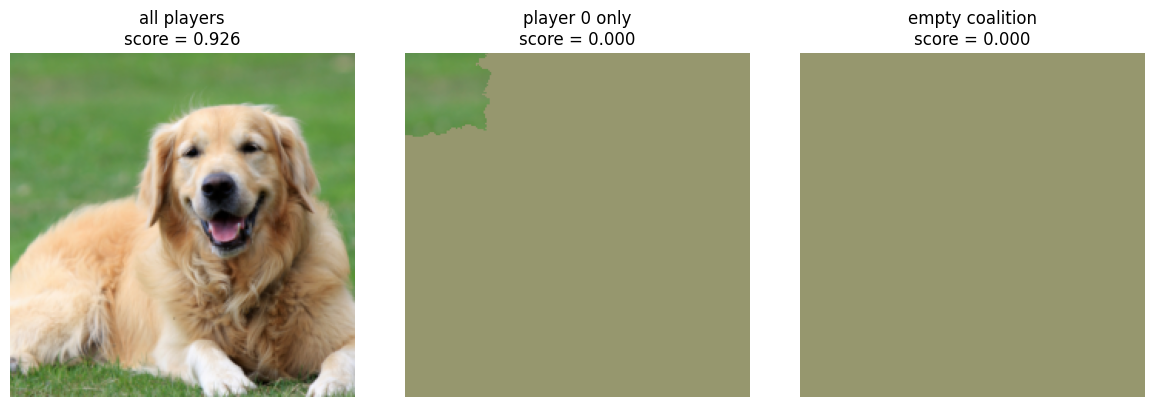

In [10]:
if RUN_REAL_EXAMPLE:
    n_players = player_masks.shape[0]
    coalitions = np.array(
        [
            np.ones(n_players, dtype=bool),
            np.array([True] + [False] * (n_players - 1)),
            np.zeros(n_players, dtype=bool),
        ]
    )
    coalition_labels = ["all players", "player 0 only", "empty coalition"]

    masked_images = masking.apply(image_224, player_masks, coalitions)
    scores = imputer.value_function(coalitions)
    print("model scores:", np.round(scores, 4))

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, masked, title, score in zip(axes, masked_images, coalition_labels, scores, strict=True):
        ax.imshow(np.clip(masked, 0, 255).astype(np.uint8))
        ax.set_title(f"{title}\nscore = {score:.3f}")
        ax.axis("off")
    plt.tight_layout()

### Explain and plot

`ImageExplainer` wraps the same imputer and runs the approximator. First-order Shapley values can be overlaid on the image with `image_attribution_plot`.

baseline: 0.0005
top-3 players by |value|: [9 2 6]


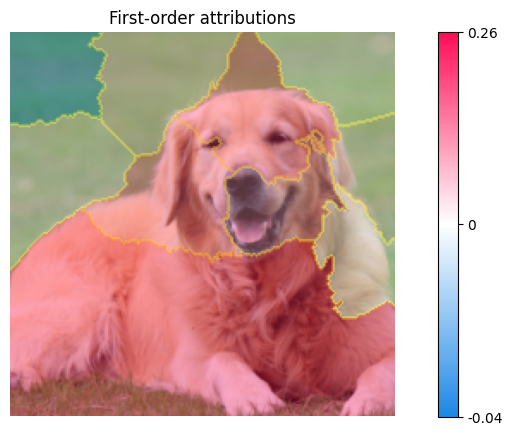

In [11]:
if RUN_REAL_EXAMPLE:
    from shapiq.plot import image_attribution_plot

    interaction_values = real_explainer.explain(budget=128)
    first_order = interaction_values.get_n_order_values(1)
    top_players = np.argsort(np.abs(first_order))[-3:][::-1]

    print(f"baseline: {real_explainer.baseline_value:.4f}")
    print(f"top-3 players by |value|: {top_players}")

    image_attribution_plot(
        interaction_values,
        image_224,
        player_masks,
        heatmap_only=True,
    )

## HuggingFace and real checkpoints

Production models need an architecture strategy that matches the checkpoint. CNN-style models can use `ResNetArchitecture` with a wrapper around your preprocessing. HuggingFace classifiers typically use `ViTArchitecture`, `ConvNeXtArchitecture`, or `HuggingFacePixelArchitecture` together with the matching processor.

When you call `Explainer(model, data=image, processor=...)`, shapiq tries to pick the right strategy from the model class name. CLIP additionally needs `text_prompts`. If auto-detection is not enough, construct the architecture yourself and pass it to `ImageExplainer`.

Tutorial 1 walks through several real architectures side by side. Tutorial 3 compares runtime against other libraries.

## Quick reference

**Typical CNN workflow**

```python
from shapiq import ImageExplainer
from shapiq.vision import MeanColorMasking, ResNetArchitecture, SuperpixelStrategy

architecture = ResNetArchitecture(model=my_resnet_fn, masking_strategy=MeanColorMasking())
explainer = ImageExplainer(
    architecture=architecture,
    data=image_224,
    player_strategy=SuperpixelStrategy(n_segments=10),
    index="SV",
    max_order=1,
    batch_size=32,
)
values = explainer.explain(budget=128)
```

**Minimal toy setup**

```python
explainer = ImageExplainer(architecture=ResNetArchitecture(model=my_fn), data=image)
values = explainer.explain(budget=128)
```

**Common kwargs on `ImageExplainer`**

| Argument | Purpose |
|----------|----------|
| `player_strategy` | How to partition the image |
| `masking_strategy` | How absent regions are filled in |
| `batch_size` | Coalitions per forward pass (`None` = all at once) |
| `index` | Interaction index, e.g. `"SV"`, `"k-SII"` |
| `max_order` | Maximum interaction order |
| `random_state` | Seed for the approximator |